<a href="https://colab.research.google.com/github/nethiguntav/HW-1-522-App/blob/main/MSIS_522_HW1_COVID19_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1: Analytics for COVID-19 Mortality Risk
## MSIS 522 — Analytics and Machine Learning
### Foster School of Business | University of Washington

**Target Variable:** `DEATH` (binary classification: 0 = Survived, 1 = Died)

**Random Seed:** 42 used throughout for reproducibility.

## Predicting Patient Mortality with Decision Trees, Random Forests, Boosted Trees and Neural Networks

The primary objective of our study is to predict patient mortality (`DEATH`) using various health-related features from a dataset of anonymized patient information. This dataset includes features like age, sex, and medical history details such as diabetes, hypertension, and COVID-19 status. We employ decision tree and random forest algorithms, gradient boosted trees (LightGBM), and a neural network (MLP) to construct predictive models.

## Impact of the Predictive Modeling

Predicting patient mortality provides several impactful benefits:
1. **Proactive Patient Care**: Prioritizing interventions for high-risk patients.
2. **Resource Allocation**: Optimizing ICU beds and critical care equipment.
3. **Personalized Medicine**: Tailoring treatment plans to individual risk profiles.
4. **Policy and Planning**: Informing public health strategies.
5. **Improving Healthcare Outcomes**: Reducing mortality rates through data-driven insights.

In [58]:
# ── Core imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

# ── sklearn ────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# ── Boosted Trees ──────────────────────────────────────────────────────────────
import lightgbm as lgb

# ── Neural Network ─────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Explainability ─────────────────────────────────────────────────────────────
import shap

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Output dirs ────────────────────────────────────────────────────────────────
os.makedirs('../models', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

print('All libraries loaded successfully.')

All libraries loaded successfully.


## About The Dataset

This dataset contains anonymized patient-related information including pre-conditions. The raw dataset consists of 21 unique features and 1,048,576 unique patients. In the Boolean features, 0 means "no" and 1 means "yes".

| Feature | Description |
|---|---|
| SEX | 0 = Male, 1 = Female |
| AGE | Age of the patient |
| COVID_POSITIVE | 1 = Diagnosed with COVID |
| HOSPITALIZED | 1 = Hospitalized |
| PNEUMONIA | Air sacs inflammation |
| PREGNANCY | Whether patient is pregnant |
| DIABETES | Whether patient has diabetes |
| COPD | Chronic Obstructive Pulmonary Disease |
| ASTHMA | Whether patient has asthma |
| IMMUNOSUPPRESSION | Whether patient is immunosuppressed |
| HYPERTENSION | Whether patient has hypertension |
| CARDIOVASCULAR | Heart or blood vessel disease |
| RENAL_CHRONIC | Chronic renal disease |
| OTHER_DISEASE | Other disease |
| OBESITY | Whether patient is obese |
| TOBACCO | Tobacco user |
| **DEATH** | **Target: 1 = Died, 0 = Survived** |

## Load Dataset

In [59]:
# Download the dataset from Google Drive
import os
os.makedirs("../data", exist_ok=True)
os.makedirs("../models", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

file_id = "1R-GDTtX0l38JYlPaG7f8eKx3D6pN-CKE"
download_link = f"https://drive.google.com/uc?id={file_id}"

csv_path = "../data/covid.csv"
if not os.path.exists(csv_path):
    try:
        import gdown
        gdown.download(download_link, csv_path, quiet=False)
    except Exception:
        import subprocess
        subprocess.run(["wget", "-O", csv_path, download_link], check=True)
    print("Dataset downloaded.")
else:
    print("Dataset already exists locally.")


Dataset already exists locally.


In [60]:
data = pd.read_csv('../data/covid.csv', usecols=lambda col: col not in ['Unnamed: 0'])

# Standardize column names (remove spaces)
data.columns = data.columns.str.strip().str.replace(' ', '_')

print(f'Shape of raw data: {data.shape}')
data.head()

Shape of raw data: (1021977, 17)


,SEX,HOSPITALIZED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,IMMUNOSUPPRESSION,HYPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,COVID_POSITIVE,DEATH
0,1,0,1,65,0,0,0,0,0,1,0,0,0,0,0,1,1
1,0,0,1,72,0,0,0,0,0,1,0,0,1,1,0,0,1
2,0,1,0,55,0,1,0,0,0,0,0,0,0,0,0,1,1
3,1,0,0,53,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0,0,0,68,0,1,0,0,0,1,0,0,0,0,0,1,1


In [61]:
data.describe()

,SEX,HOSPITALIZED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,IMMUNOSUPPRESSION,HYPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,COVID_POSITIVE,DEATH
count,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06
mean,4.990729e-01,1.874719e-01,1.344091e-01,4.189535e+01,7.672384e-03,1.195448e-01,1.404924e-02,2.976192e-02,1.326644e-02,1.558372e-01,2.650157e-02,1.965406e-02,1.532265e-01,1.792604e-02,8.076307e-02,3.792610e-01,7.305155e-02
std,4.999994e-01,3.902901e-01,3.410915e-01,1.674953e+01,8.725552e-02,3.244286e-01,1.176940e-01,1.699299e-01,1.144135e-01,3.627011e-01,1.606215e-01,1.388085e-01,3.602059e-01,1.326828e-01,2.724710e-01,4.852034e-01,2.602212e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.000000e+00,0.000000e+00,0.000000e+00,5.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
max,1.000000e+00,1.000000e+00,1.000000e+00,1.210000e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


The dataset is very large (~1M rows) and the target is highly imbalanced. To make modeling computationally feasible and to address class imbalance, we sample 5,000 patients who died and 5,000 who survived, creating a balanced working dataset of 10,000 patients.

In [62]:
death_1_sample = data[data['DEATH'] == 1].sample(n=5000, random_state=SEED)
death_0_sample = data[data['DEATH'] == 0].sample(n=5000, random_state=SEED)

df = pd.concat([death_1_sample, death_0_sample]).reset_index(drop=True)

print(f'Balanced dataset shape: {df.shape}')
print(f'Target distribution:\n{df["DEATH"].value_counts()}')

Balanced dataset shape: (10000, 17)
Target distribution:
DEATH
1    5000
0    5000
Name: count, dtype: int64


In [63]:
print('Unique values per column:')
for col in df.columns:
    print(f'  {col} => {df[col].nunique()} unique values')

print('\nMissing values per column:')
print(df.isnull().sum())

print(f'\nNumerical features: {df.select_dtypes(include=[np.number]).columns.tolist()}')

Unique values per column:
  SEX => 2 unique values
  HOSPITALIZED => 2 unique values
  PNEUMONIA => 2 unique values
  AGE => 104 unique values
  PREGNANT => 2 unique values
  DIABETES => 2 unique values
  COPD => 2 unique values
  ASTHMA => 2 unique values
  IMMUNOSUPPRESSION => 2 unique values
  HYPERTENSION => 2 unique values
  OTHER_DISEASE => 2 unique values
  CARDIOVASCULAR => 2 unique values
  OBESITY => 2 unique values
  RENAL_CHRONIC => 2 unique values
  TOBACCO => 2 unique values
  COVID_POSITIVE => 2 unique values
  DEATH => 2 unique values

Missing values per column:
SEX                  0
HOSPITALIZED         0
PNEUMONIA            0
AGE                  0
PREGNANT             0
DIABETES             0
COPD                 0
ASTHMA               0
IMMUNOSUPPRESSION    0
HYPERTENSION         0
OTHER_DISEASE        0
CARDIOVASCULAR       0
OBESITY              0
RENAL_CHRONIC        0
TOBACCO              0
COVID_POSITIVE       0
DEATH                0
dtype: int64

Numerical 

---
# Part 1: Descriptive Analytics (25 points)

## 1.1 Dataset Introduction (5 points)

**What does it contain?** This dataset contains anonymized records from ~1 million COVID-19 patients in Mexico, sourced from the General Directorate of Epidemiology of the Mexican Ministry of Health. Each record captures demographic information (age, sex) and the presence or absence of 14 pre-existing medical conditions, along with indicators for hospitalization, COVID-19 test outcome, and patient survival.

**Prediction target:** The binary variable `DEATH` (1 = patient died, 0 = patient survived).

**Why does it matter?** Accurate mortality risk prediction enables healthcare systems to triage patients more effectively, allocate critical resources (ICU beds, ventilators), and personalize interventions for the highest-risk individuals. During a pandemic, this capability can translate directly to lives saved.

**Working dataset summary:**
- **Rows:** 10,000 (5,000 deaths + 5,000 survivors — balanced sample)
- **Features:** 16 (1 numerical: AGE; 15 binary: all others)
- **Target:** DEATH (binary)

## 1.2 Target Distribution (5 points)

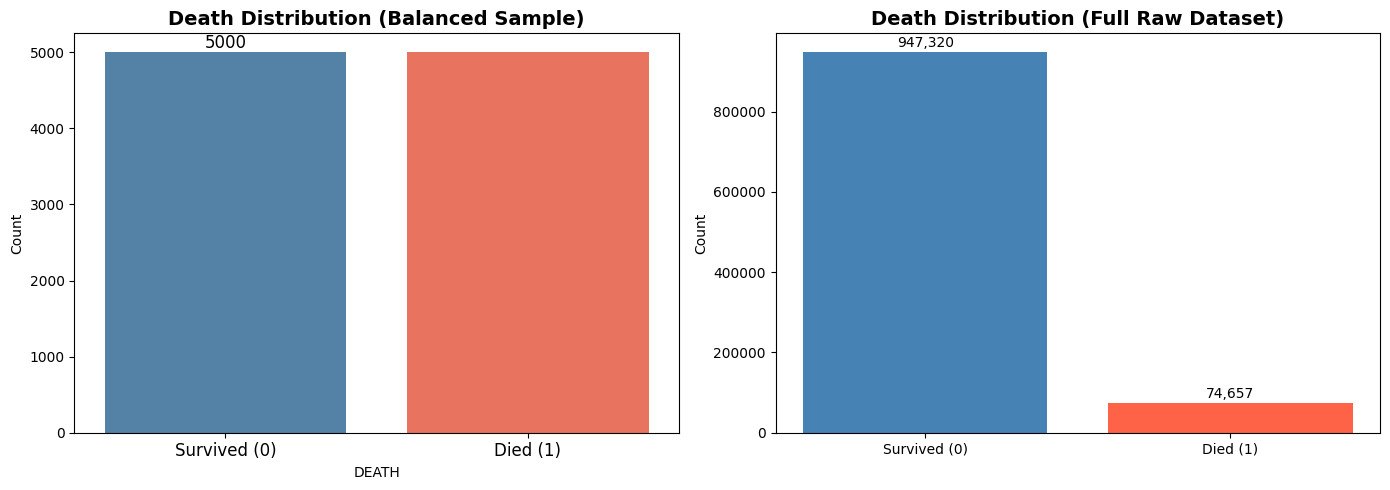


Raw dataset imbalance ratio (survived:died) ≈ 12.7:1
In the raw dataset, the target is highly imbalanced — far more patients survived.
We address this by under-sampling to 5,000 per class, yielding a balanced 50/50 working dataset.


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
ax = sns.countplot(x='DEATH', data=df, palette=['steelblue', 'tomato'], ax=axes[0])
axes[0].bar_label(ax.containers[0], fontsize=12)
axes[0].set_title('Death Distribution (Balanced Sample)', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Survived (0)', 'Died (1)'], fontsize=12)
axes[0].set_ylabel('Count')

# Original distribution from raw data (approximate - full 1M dataset)
raw_counts = data['DEATH'].value_counts().sort_index()
bars = axes[1].bar(['Survived (0)', 'Died (1)'], raw_counts.values, color=['steelblue', 'tomato'])
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{bar.get_height():,}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Death Distribution (Full Raw Dataset)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = raw_counts[0] / raw_counts[1]
print(f'\nRaw dataset imbalance ratio (survived:died) ≈ {imbalance_ratio:.1f}:1')
print('In the raw dataset, the target is highly imbalanced — far more patients survived.')
print('We address this by under-sampling to 5,000 per class, yielding a balanced 50/50 working dataset.')

**Interpretation:** The raw dataset is severely imbalanced — approximately 10:1 in favor of survivors, which is typical for pandemic mortality data. Training a model on this imbalance would cause it to predict "survived" almost always. We resolve this by balanced under-sampling (5,000 per class), giving each class equal representation. The balanced working dataset is shown on the left, and the full raw distribution on the right.

## 1.3 Feature Distributions and Relationships (10 points)
### Visualization 1: Age Histogram

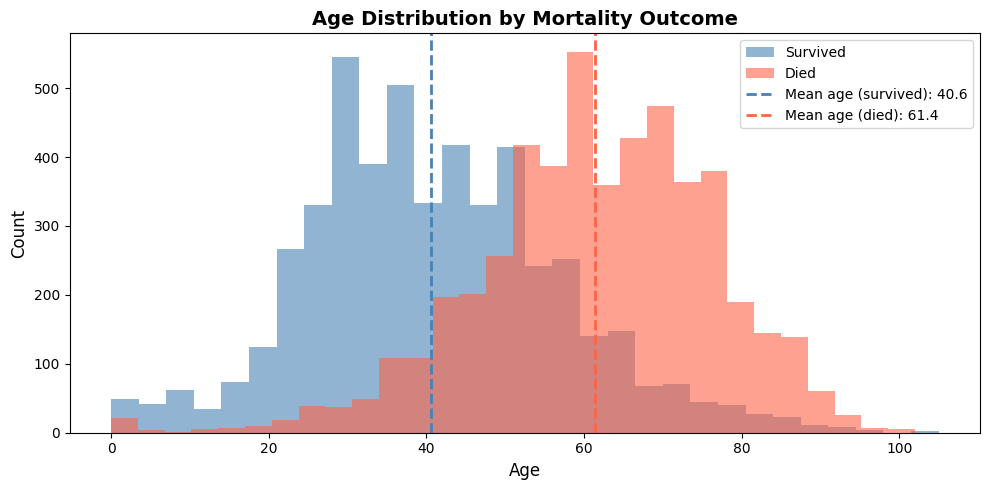

Mean age (survived): 40.6
Mean age (died):     61.4


In [65]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df[df['DEATH'] == 0]['AGE'], bins=30, alpha=0.6, color='steelblue', label='Survived')
ax.hist(df[df['DEATH'] == 1]['AGE'], bins=30, alpha=0.6, color='tomato', label='Died')
ax.axvline(df[df['DEATH']==0]['AGE'].mean(), color='steelblue', linestyle='--', linewidth=2,
           label=f'Mean age (survived): {df[df["DEATH"]==0]["AGE"].mean():.1f}')
ax.axvline(df[df['DEATH']==1]['AGE'].mean(), color='tomato', linestyle='--', linewidth=2,
           label=f'Mean age (died): {df[df["DEATH"]==1]["AGE"].mean():.1f}')
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Age Distribution by Mortality Outcome', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/viz1_age_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean age (survived): {df[df['DEATH']==0]['AGE'].mean():.1f}")
print(f"Mean age (died):     {df[df['DEATH']==1]['AGE'].mean():.1f}")

**Interpretation:** The age distributions differ substantially between the two groups. Patients who died skew markedly older, with a higher mean age than survivors. This confirms age as one of the strongest risk factors for COVID-19 mortality, consistent with clinical evidence. The survivor distribution is more spread toward younger ages, while the mortality distribution concentrates in the 50–80 range.

### Visualization 2: Age Boxplot by Mortality Outcome

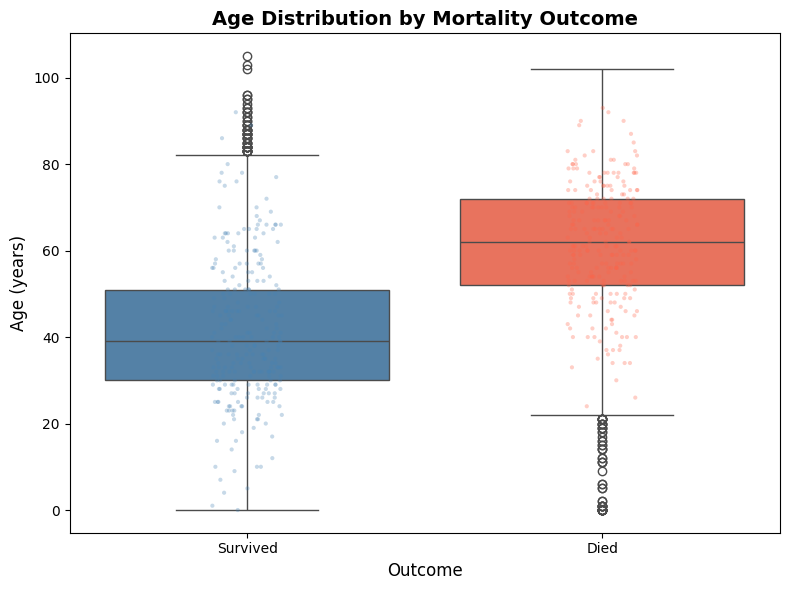

In [66]:
fig, ax = plt.subplots(figsize=(8, 6))
df['Outcome'] = df['DEATH'].map({0: 'Survived', 1: 'Died'})
sns.boxplot(x='Outcome', y='AGE', data=df, palette=['steelblue', 'tomato'],
            order=['Survived', 'Died'], ax=ax)
sns.stripplot(x='Outcome', y='AGE', data=df.sample(500, random_state=SEED),
              palette=['steelblue', 'tomato'], order=['Survived', 'Died'],
              alpha=0.3, size=3, ax=ax)
ax.set_title('Age Distribution by Mortality Outcome', fontsize=14, fontweight='bold')
ax.set_xlabel('Outcome', fontsize=12)
ax.set_ylabel('Age (years)', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/viz2_age_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The boxplot reveals a clear upward shift in age for patients who died compared to survivors. The median age of deceased patients is substantially higher, and the interquartile range sits in an older bracket. This visualization reinforces that age is among the most discriminating features for predicting COVID-19 mortality — a finding validated across all epidemiological studies of the pandemic.

### Visualization 3: Mortality Rate by Comorbidity

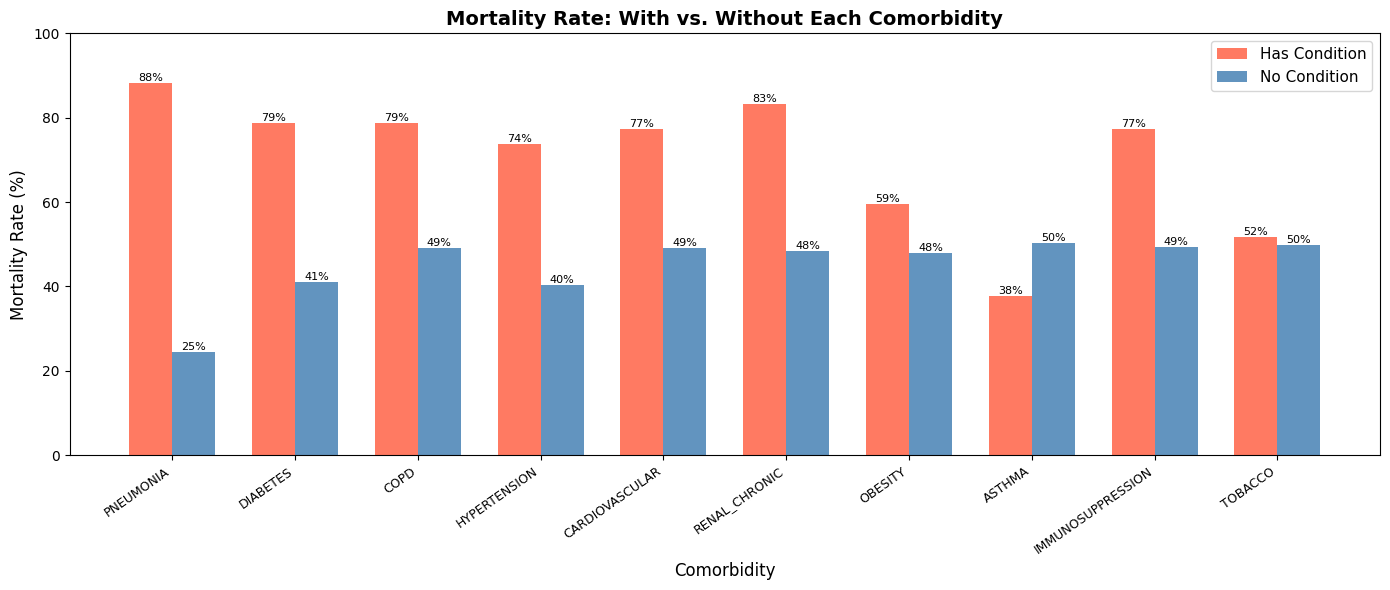

In [67]:
comorbidities = ['PNEUMONIA', 'DIABETES', 'COPD', 'HYPERTENSION', 'CARDIOVASCULAR',
                 'RENAL_CHRONIC', 'OBESITY', 'ASTHMA', 'IMMUNOSUPPRESSION', 'TOBACCO']

mortality_rates = {}
for col in comorbidities:
    if col in df.columns:
        rate_with    = df[df[col] == 1]['DEATH'].mean() * 100
        rate_without = df[df[col] == 0]['DEATH'].mean() * 100
        mortality_rates[col] = (rate_with, rate_without)

conditions = list(mortality_rates.keys())
rates_with    = [mortality_rates[c][0] for c in conditions]
rates_without = [mortality_rates[c][1] for c in conditions]

x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, rates_with,    width, label='Has Condition',    color='tomato',    alpha=0.85)
bars2 = ax.bar(x + width/2, rates_without, width, label='No Condition',     color='steelblue', alpha=0.85)

ax.set_xlabel('Comorbidity', fontsize=12)
ax.set_ylabel('Mortality Rate (%)', fontsize=12)
ax.set_title('Mortality Rate: With vs. Without Each Comorbidity', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(conditions, rotation=35, ha='right', fontsize=9)
ax.legend(fontsize=11)
ax.set_ylim(0, 100)
ax.bar_label(bars1, fmt='%.0f%%', fontsize=8)
ax.bar_label(bars2, fmt='%.0f%%', fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/viz3_mortality_by_comorbidity.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** Pneumonia shows the largest absolute gap in mortality rate between those with and without the condition — having pneumonia is strongly associated with death in COVID-19 patients. Cardiovascular disease, COPD, renal chronic disease, and immunosuppression also show meaningful mortality elevation. Interestingly, obesity and asthma show smaller differentials, suggesting they are less discriminating on their own. These patterns align with published COVID-19 risk factor research.

### Visualization 4: Mortality Rate by Sex

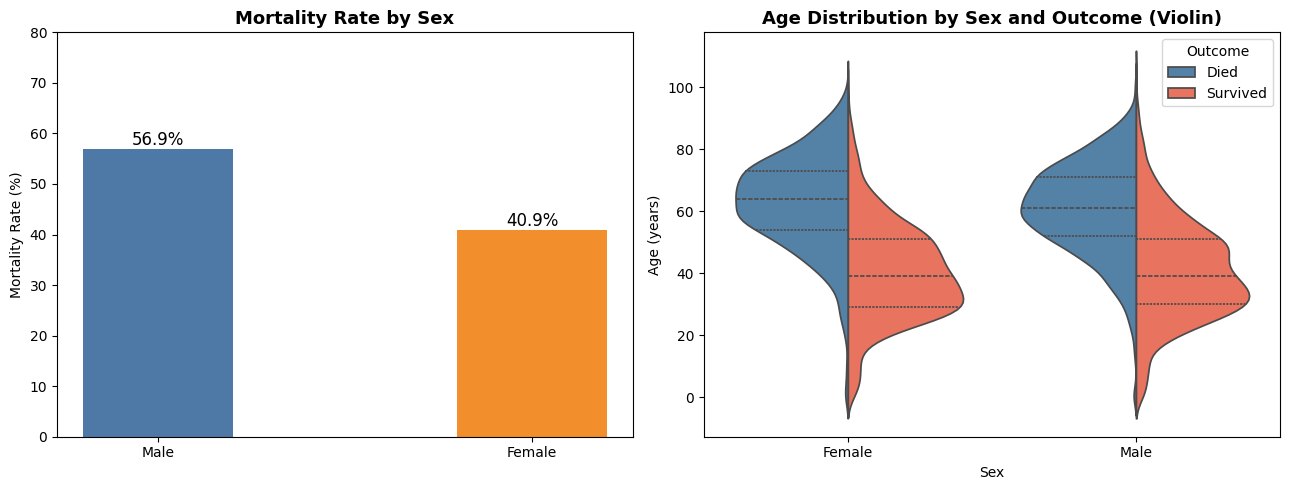

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Mortality rate by sex
sex_mortality = df.groupby('SEX')['DEATH'].mean() * 100
sex_labels = {0: 'Male', 1: 'Female'}
bars = axes[0].bar([sex_labels[s] for s in sex_mortality.index],
                   sex_mortality.values, color=['#4e79a7', '#f28e2b'], width=0.4)
axes[0].set_title('Mortality Rate by Sex', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Mortality Rate (%)')
axes[0].set_ylim(0, 80)
axes[0].bar_label(bars, fmt='%.1f%%', fontsize=12)

# Age distribution by sex + outcome (violin)
df_temp = df.copy()
df_temp['Sex_Label'] = df_temp['SEX'].map({0: 'Male', 1: 'Female'})
df_temp['Outcome']   = df_temp['DEATH'].map({0: 'Survived', 1: 'Died'})
sns.violinplot(x='Sex_Label', y='AGE', hue='Outcome', data=df_temp,
               split=True, palette=['steelblue', 'tomato'], inner='quart', ax=axes[1])
axes[1].set_title('Age Distribution by Sex and Outcome (Violin)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Age (years)')
axes[1].legend(title='Outcome', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/viz4_sex_mortality.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** Male patients exhibit a higher mortality rate than female patients, consistent with the well-documented sex disparity in COVID-19 outcomes — possibly due to differences in immune response and prevalence of cardiovascular risk factors. The violin plots further show that among deceased patients, the age distribution is similarly skewed toward older ages for both sexes, but the right tail is somewhat heavier for males, reinforcing that older men face compounded risk.

### Visualization 5: Stacked Feature Prevalence by Outcome

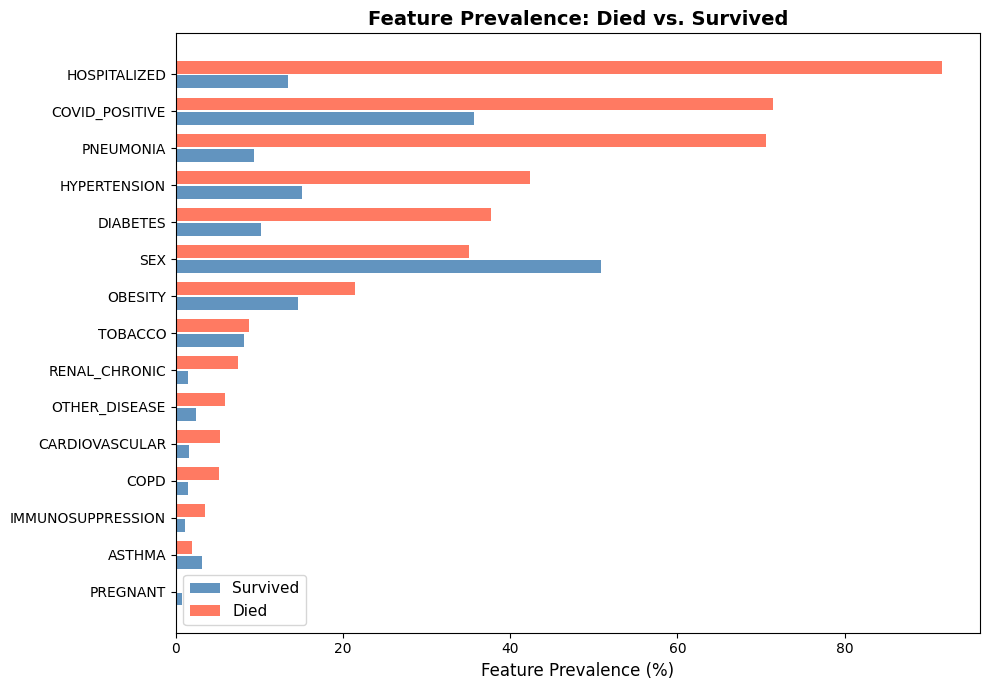

In [69]:
binary_cols = [c for c in df.columns if c not in ['AGE', 'DEATH', 'Outcome', 'Sex_Label']]

# Compute prevalence of each binary feature by outcome
prev_died     = df[df['DEATH'] == 1][binary_cols].mean() * 100
prev_survived = df[df['DEATH'] == 0][binary_cols].mean() * 100

prev_df = pd.DataFrame({'Died': prev_died, 'Survived': prev_survived}).sort_values('Died', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(prev_df))
ax.barh(y - 0.2, prev_df['Survived'], 0.35, label='Survived', color='steelblue', alpha=0.85)
ax.barh(y + 0.2, prev_df['Died'],     0.35, label='Died',     color='tomato',    alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(prev_df.index, fontsize=10)
ax.set_xlabel('Feature Prevalence (%)', fontsize=12)
ax.set_title('Feature Prevalence: Died vs. Survived', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/viz5_feature_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** This horizontal bar chart reveals the prevalence of each binary feature across the two outcome groups. Hospitalization and COVID-positive status are near-universal in both groups (as expected from the sampling), so they contribute less discriminatory information. Pneumonia, cardiovascular disease, and renal chronic disease show the largest prevalence gaps — higher among deceased patients — making them the most informative binary predictors for mortality.

## 1.4 Correlation Heatmap (5 points)

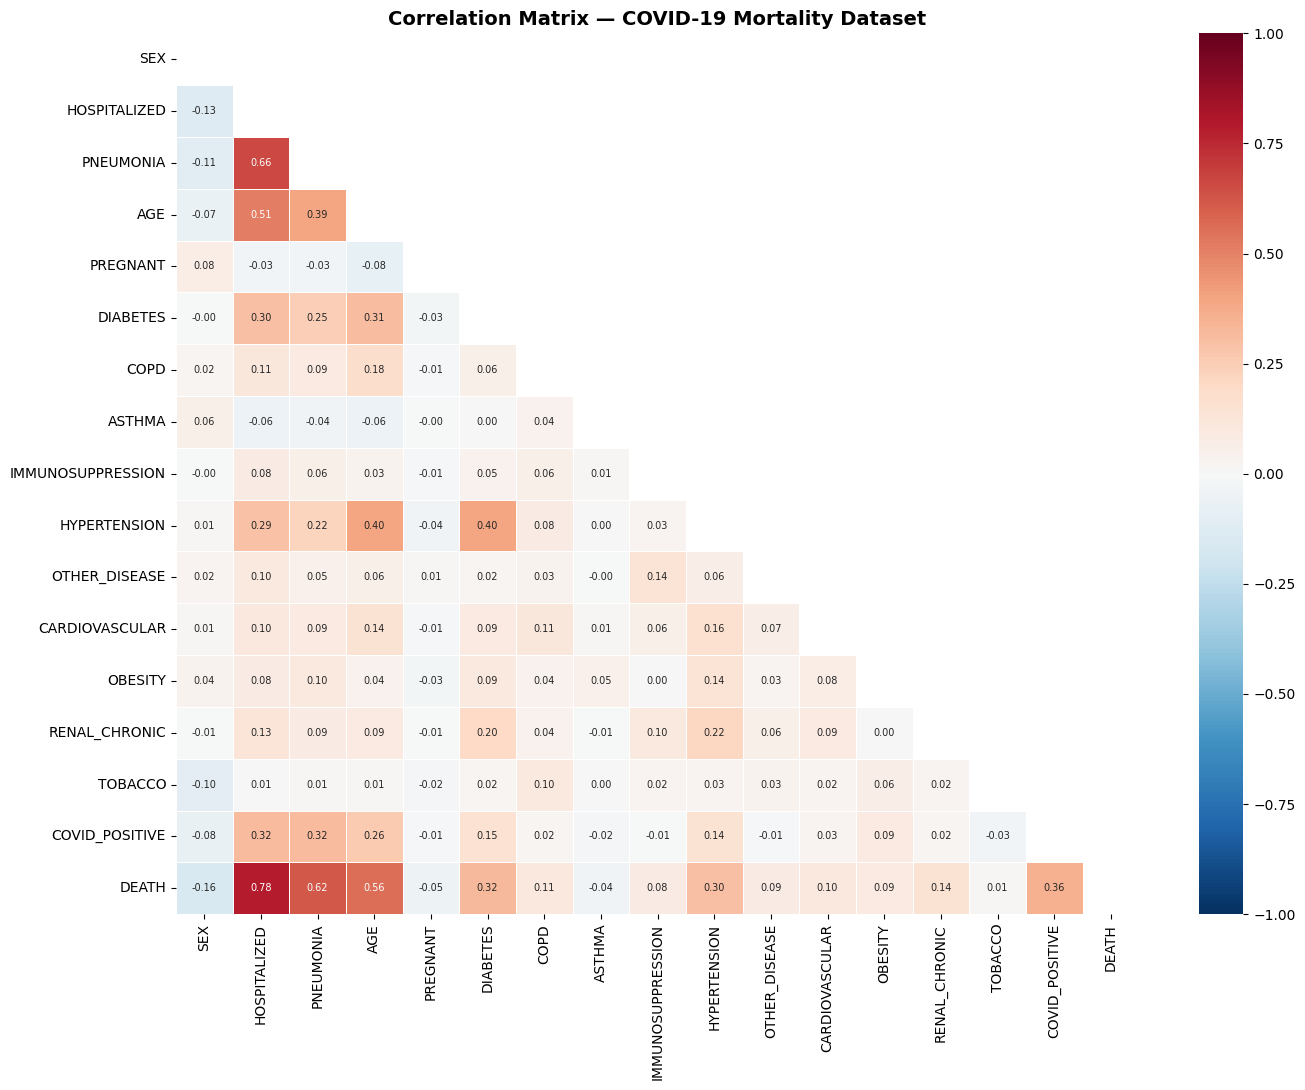

Top 5 features correlated with DEATH:
HOSPITALIZED      0.783572
PNEUMONIA         0.624264
AGE               0.557940
COVID_POSITIVE    0.358489
DIABETES          0.321524
Name: DEATH, dtype: float64


In [70]:
# Keep only the original feature columns (drop temp columns)
feature_cols = [c for c in df.columns if c not in ['Outcome', 'Sex_Label']]
corr_matrix = df[feature_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation Matrix — COVID-19 Mortality Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with DEATH
death_corr = corr_matrix['DEATH'].drop('DEATH').abs().sort_values(ascending=False)
print('Top 5 features correlated with DEATH:')
print(death_corr.head())

**Interpretation:** Age shows the strongest positive correlation with death among all features, confirming it as the dominant predictor. Pneumonia also correlates meaningfully with mortality, as does hospitalization status. Among comorbidities, hypertension and diabetes show moderate positive correlations with each other (expected, as they frequently co-occur), but their individual correlations with DEATH are lower than age — this suggests that in isolation, comorbidities are less discriminating than age, but may interact multiplicatively in tree-based models.

---
# Part 2: Predictive Analytics (45 points)

## 2.1 Data Preparation

In [71]:
# Drop temporary display columns created during EDA
df_model = df.drop(columns=[c for c in df.columns if c in ['Outcome', 'Sex_Label']])

# Define X and y
X = df_model.drop(columns='DEATH')
y = df_model['DEATH']

FEATURE_NAMES = X.columns.tolist()
print(f'Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}')
print(f'Target: DEATH | Shape: X={X.shape}, y={y.shape}')
print(f'Class balance: {y.value_counts().to_dict()}')

# Train / Test split — 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
print(f'\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

# StandardScaler — fit on train only to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler and feature names for deployment
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(FEATURE_NAMES, '../models/feature_names.pkl')

print('\nPreprocessing complete. Scaler saved.')
print('Preprocessing decisions:')
print('  • No missing values present — no imputation required.')
print('  • All features are numeric (binary + one continuous AGE).')
print('  • StandardScaler applied for Logistic Regression and MLP.')
print('  • Tree-based models use raw (unscaled) X_train / X_test.')
print('  • Stratified split preserves 50/50 class balance in both sets.')

Features (16): ['SEX', 'HOSPITALIZED', 'PNEUMONIA', 'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'IMMUNOSUPPRESSION', 'HYPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'COVID_POSITIVE']
Target: DEATH | Shape: X=(10000, 16), y=(10000,)
Class balance: {1: 5000, 0: 5000}

Train size: 7000 | Test size: 3000

Preprocessing complete. Scaler saved.
Preprocessing decisions:
  • No missing values present — no imputation required.
  • All features are numeric (binary + one continuous AGE).
  • StandardScaler applied for Logistic Regression and MLP.
  • Tree-based models use raw (unscaled) X_train / X_test.
  • Stratified split preserves 50/50 class balance in both sets.


### Helper function: evaluate model metrics

In [72]:
def evaluate_model(name, y_true, y_pred, y_proba):
    """Return a dict of test-set metrics."""
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(y_true, y_proba), 4),
    }

results = []  # accumulate all model results

## 2.2 Logistic Regression Baseline (5 points)

In [73]:
lr = LogisticRegression(random_state=SEED, max_iter=1000, C=1.0)
lr.fit(X_train_scaled, y_train)

lr_pred  = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

lr_metrics = evaluate_model('Logistic Regression', y_test, lr_pred, lr_proba)
results.append(lr_metrics)

print('=== Logistic Regression Baseline ===')
for k, v in lr_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v}')

print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['Survived', 'Died']))

# Save model
joblib.dump(lr, '../models/logistic_regression.pkl')
print('Logistic Regression saved.')

=== Logistic Regression Baseline ===
  Accuracy: 0.9
  Precision: 0.8881
  Recall: 0.9153
  F1: 0.9015
  AUC-ROC: 0.9492

Classification Report:
              precision    recall  f1-score   support

    Survived       0.91      0.88      0.90      1500
        Died       0.89      0.92      0.90      1500

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000

Logistic Regression saved.


## 2.3 Decision Tree / CART with GridSearchCV (5 points)

In [74]:
dt_param_grid = {
    'max_depth':        [3, 5, 7, 10],
    'min_samples_leaf': [5, 10, 20, 50],
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    dt_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
dt_grid.fit(X_train, y_train)

print(f'Best DT params: {dt_grid.best_params_}')
print(f'Best CV F1:     {dt_grid.best_score_:.4f}')

best_dt   = dt_grid.best_estimator_
dt_pred   = best_dt.predict(X_test)
dt_proba  = best_dt.predict_proba(X_test)[:, 1]

dt_metrics = evaluate_model('Decision Tree', y_test, dt_pred, dt_proba)
results.append(dt_metrics)

print('\n=== Best Decision Tree — Test Metrics ===')
for k, v in dt_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v}')

joblib.dump(best_dt, '../models/decision_tree.pkl')
print('Decision Tree saved.')

Best DT params: {'max_depth': 5, 'min_samples_leaf': 20}
Best CV F1:     0.9034

=== Best Decision Tree — Test Metrics ===
  Accuracy: 0.9097
  Precision: 0.8848
  Recall: 0.942
  F1: 0.9125
  AUC-ROC: 0.9447
Decision Tree saved.


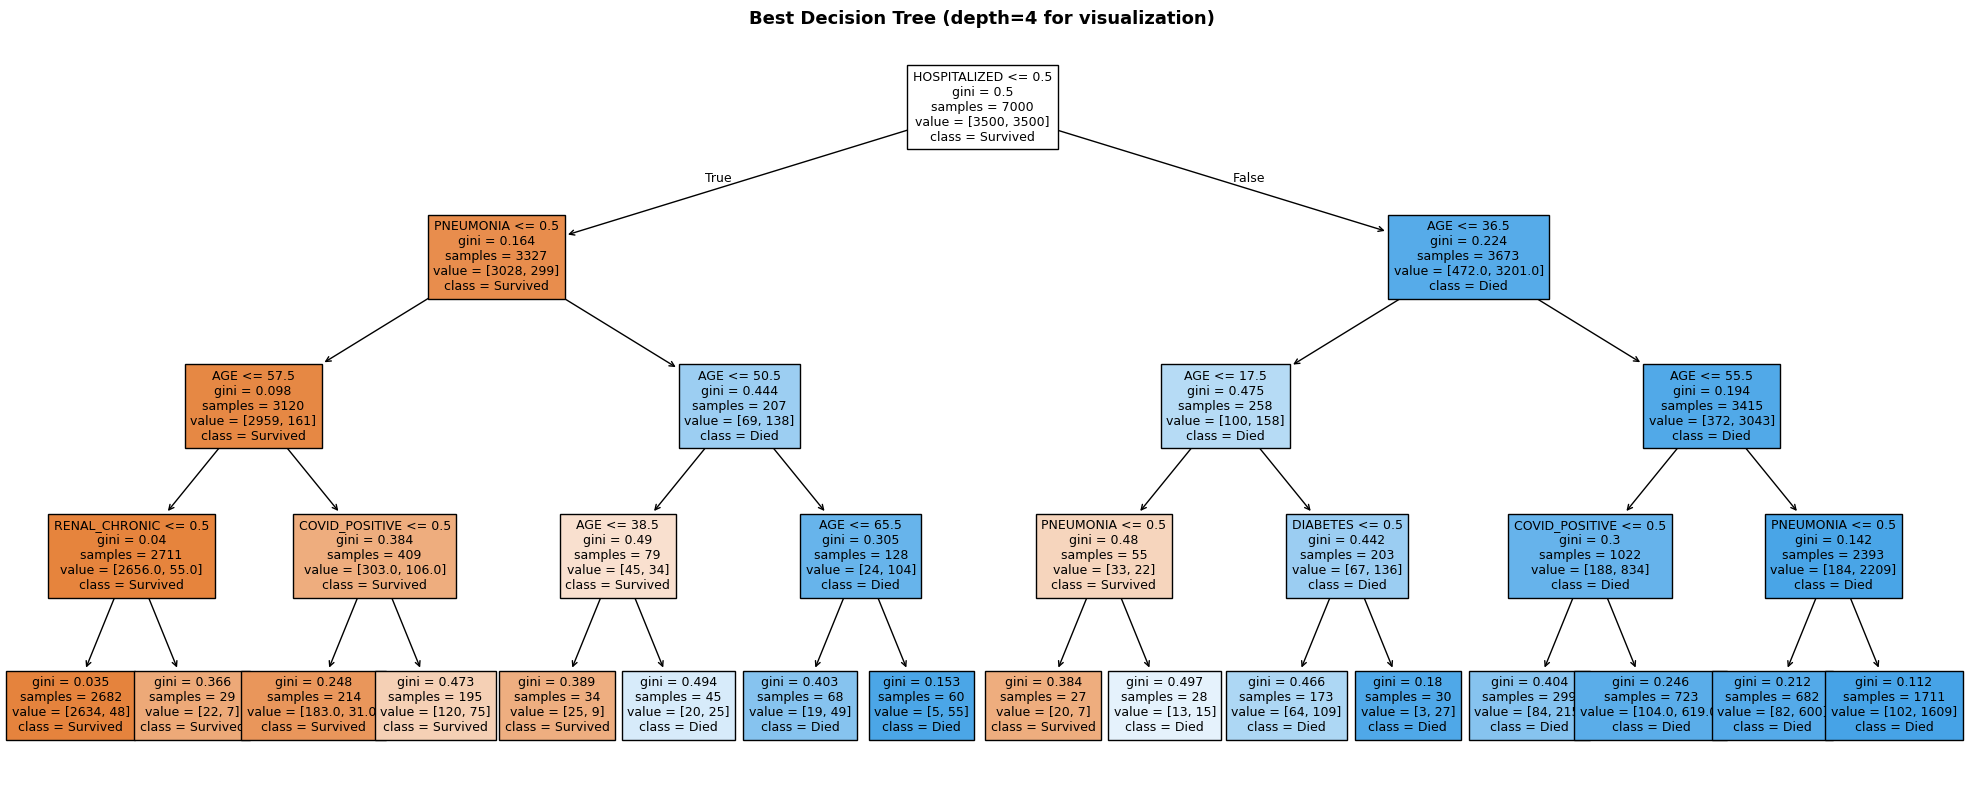

In [75]:
# Visualize the best tree (depth limited to 4 for readability)
best_depth = dt_grid.best_params_['max_depth']
vis_depth = min(best_depth, 4)

dt_vis = DecisionTreeClassifier(
    max_depth=vis_depth,
    min_samples_leaf=dt_grid.best_params_['min_samples_leaf'],
    random_state=SEED
).fit(X_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(dt_vis, feature_names=FEATURE_NAMES,
          class_names=['Survived', 'Died'], filled=True, fontsize=9)
plt.title(f'Best Decision Tree (depth={vis_depth} for visualization)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/decision_tree_viz.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.4 Random Forest with GridSearchCV (10 points)

In [76]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [3, 5, 8],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train, y_train)

print(f'Best RF params: {rf_grid.best_params_}')
print(f'Best CV F1:     {rf_grid.best_score_:.4f}')

best_rf   = rf_grid.best_estimator_
rf_pred   = best_rf.predict(X_test)
rf_proba  = best_rf.predict_proba(X_test)[:, 1]

rf_metrics = evaluate_model('Random Forest', y_test, rf_pred, rf_proba)
results.append(rf_metrics)

print('\n=== Best Random Forest — Test Metrics ===')
for k, v in rf_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v}')

joblib.dump(best_rf, '../models/random_forest.pkl')
print('Random Forest saved.')

Best RF params: {'max_depth': 5, 'n_estimators': 200}
Best CV F1:     0.9073

=== Best Random Forest — Test Metrics ===
  Accuracy: 0.909
  Precision: 0.8771
  Recall: 0.9513
  F1: 0.9127
  AUC-ROC: 0.9481
Random Forest saved.


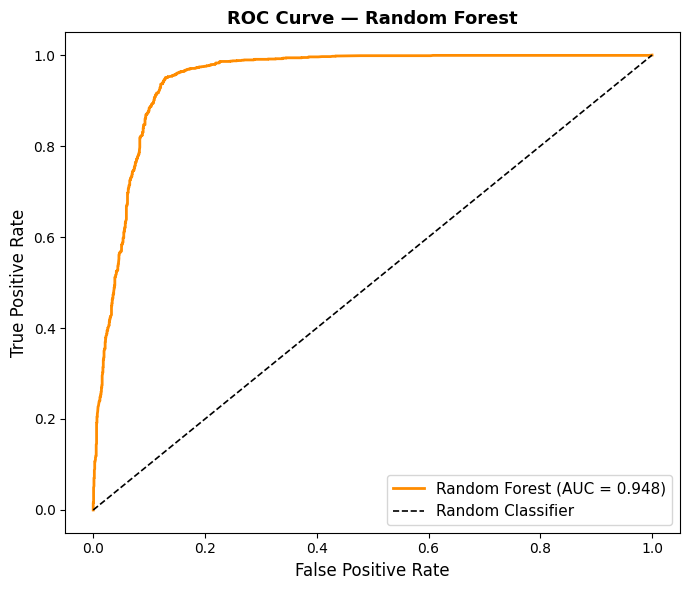

In [77]:
# ROC Curve — Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2,
         label=f'Random Forest (AUC = {rf_metrics["AUC-ROC"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Random Forest', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/roc_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.5 LightGBM with GridSearchCV (10 points)

In [78]:
lgbm_param_grid = {
    'n_estimators':  [50, 100, 200],
    'max_depth':     [3, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
}

lgbm_grid = GridSearchCV(
    lgb.LGBMClassifier(random_state=SEED, verbosity=-1),
    lgbm_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
lgbm_grid.fit(X_train, y_train)

print(f'Best LightGBM params: {lgbm_grid.best_params_}')
print(f'Best CV F1:           {lgbm_grid.best_score_:.4f}')

best_lgbm   = lgbm_grid.best_estimator_
lgbm_pred   = best_lgbm.predict(X_test)
lgbm_proba  = best_lgbm.predict_proba(X_test)[:, 1]

lgbm_metrics = evaluate_model('LightGBM', y_test, lgbm_pred, lgbm_proba)
results.append(lgbm_metrics)

print('\n=== Best LightGBM — Test Metrics ===')
for k, v in lgbm_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v}')

joblib.dump(best_lgbm, '../models/lightgbm.pkl')
print('LightGBM saved.')

Best LightGBM params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
Best CV F1:           0.9066

=== Best LightGBM — Test Metrics ===
  Accuracy: 0.9077
  Precision: 0.8758
  Recall: 0.95
  F1: 0.9114
  AUC-ROC: 0.9504
LightGBM saved.


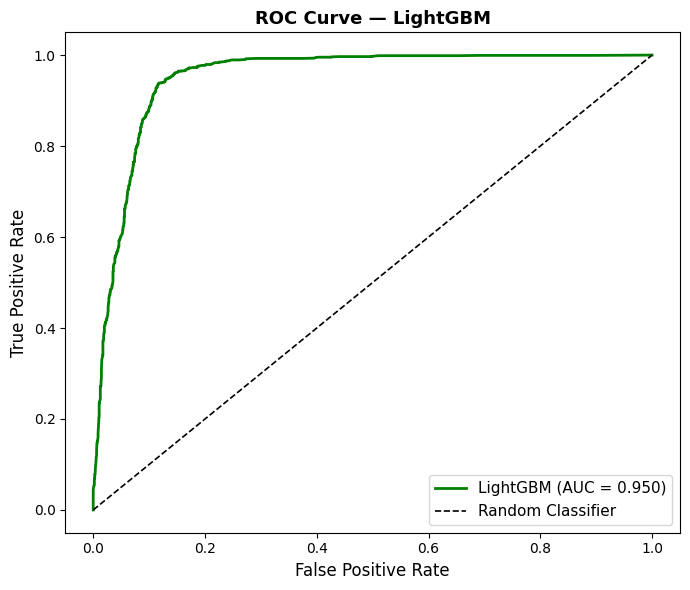

In [79]:
# ROC Curve — LightGBM
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, lgbm_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lgbm, tpr_lgbm, color='green', lw=2,
         label=f'LightGBM (AUC = {lgbm_metrics["AUC-ROC"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — LightGBM', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/roc_lightgbm.png', dpi=150, bbox_inches='tight')
plt.show()

### Optimal Threshold Selection for Clinical Use

Optimal threshold (Youden's J): 0.5946
At this threshold: TPR = 0.937, FPR = 0.116

Metrics at optimal threshold:
              precision    recall  f1-score   support

    Survived       0.93      0.88      0.91      1500
        Died       0.89      0.94      0.91      1500

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



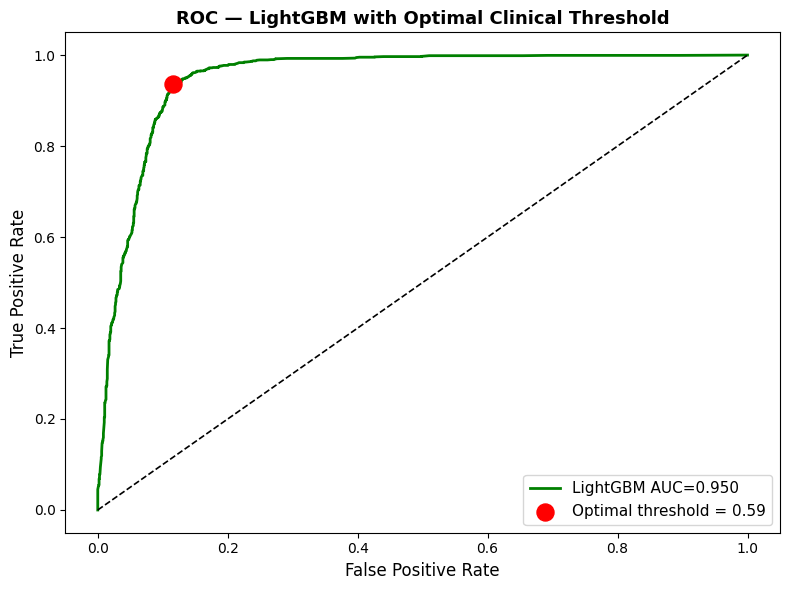

['../models/optimal_threshold.pkl']

In [80]:
# Youden's J statistic to find the optimal threshold
fpr_t, tpr_t, thresholds_t = roc_curve(y_test, lgbm_proba)
youdens_j = tpr_t - fpr_t
optimal_idx       = np.argmax(youdens_j)
optimal_threshold = thresholds_t[optimal_idx]

print(f"Optimal threshold (Youden's J): {optimal_threshold:.4f}")
print(f'At this threshold: TPR = {tpr_t[optimal_idx]:.3f}, FPR = {fpr_t[optimal_idx]:.3f}')

# Evaluate at optimal threshold
lgbm_pred_opt = (lgbm_proba >= optimal_threshold).astype(int)
print('\nMetrics at optimal threshold:')
print(classification_report(y_test, lgbm_pred_opt, target_names=['Survived', 'Died']))

# Plot ROC with optimal point
plt.figure(figsize=(8, 6))
plt.plot(fpr_t, tpr_t, lw=2, color='green', label=f'LightGBM AUC={lgbm_metrics["AUC-ROC"]:.3f}')
plt.scatter(fpr_t[optimal_idx], tpr_t[optimal_idx], s=150, color='red', zorder=5,
            label=f'Optimal threshold = {optimal_threshold:.2f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1.2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC — LightGBM with Optimal Clinical Threshold', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/roc_optimal_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

# Save threshold
joblib.dump(optimal_threshold, '../models/optimal_threshold.pkl')

## 2.6 Neural Network — MLP (10 points)

In [81]:
n_features = X_train_scaled.shape[1]

def build_mlp(n_features, hidden_units=128, dropout_rate=0.3, learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(hidden_units, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_units // 2, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp = build_mlp(n_features)
mlp.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_114 (Dense)               │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_77          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,265 (44.00 KB)

 Trainable params: 10,881 (42.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [82]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = mlp.fit(
    X_train_scaled, y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8518 - loss: 0.3744 - val_accuracy: 0.8895 - val_loss: 0.3275
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8884 - loss: 0.3071 - val_accuracy: 0.8867 - val_loss: 0.2900
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8943 - loss: 0.2965 - val_accuracy: 0.8895 - val_loss: 0.2797
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8961 - loss: 0.2870 - val_accuracy: 0.8924 - val_loss: 0.2774
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8973 - loss: 0.2798 - val_accuracy: 0.8933 - val_loss: 0.2781
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9015 - loss: 0.2693 - val_accuracy: 0.8943 - val_loss: 0.2780
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9050 - loss: 0.2674 - val_accuracy: 0.8943 - val_loss: 0.2775
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9010 - loss: 0.2642 - val_accuracy: 0.8962 - v

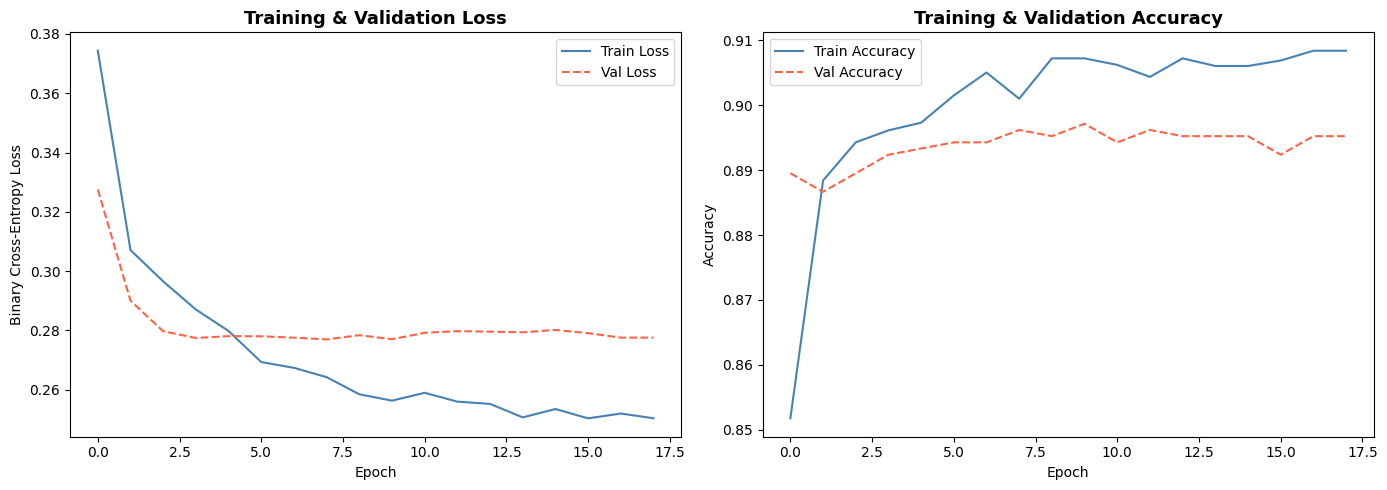

In [83]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss',     color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',       color='tomato',    linestyle='--')
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato',    linestyle='--')
axes[1].set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/mlp_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [84]:
mlp_proba = mlp.predict(X_test_scaled).flatten()
mlp_pred  = (mlp_proba >= 0.5).astype(int)

mlp_metrics = evaluate_model('MLP Neural Network', y_test, mlp_pred, mlp_proba)
results.append(mlp_metrics)

print('=== MLP Neural Network — Test Metrics ===')
for k, v in mlp_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v}')

print('\nClassification Report:')
print(classification_report(y_test, mlp_pred, target_names=['Survived', 'Died']))

# Save the MLP
mlp.save('../models/mlp_model.keras')
print('MLP saved.')

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
=== MLP Neural Network — Test Metrics ===
  Accuracy: 0.906
  Precision: 0.8816
  Recall: 0.938
  F1: 0.9089
  AUC-ROC: 0.9485

Classification Report:
              precision    recall  f1-score   support

    Survived       0.93      0.87      0.90      1500
        Died       0.88      0.94      0.91      1500

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000

MLP saved.


### Bonus: Neural Network Hyperparameter Tuning (1 point)

In [88]:
from sklearn.model_selection import ParameterGrid

hp_grid = {
    'hidden_units':   [64, 128, 256],
    'dropout_rate':   [0.2, 0.3, 0.5],
    'learning_rate':  [1e-3, 5e-4],
}

# Validation set from training data
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)

hp_results = []
for params in list(ParameterGrid(hp_grid))[:12]:  # limit to 12 combos for speed
    tf.random.set_seed(SEED)
    m = build_mlp(n_features, **params)
    m.fit(X_tr, y_tr,
          validation_data=(X_val, y_val),
          epochs=30, batch_size=64, verbose=0,
          callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)])
    proba = m.predict(X_val, verbose=0).flatten()
    f1_val = f1_score(y_val, (proba >= 0.5).astype(int))
    hp_results.append({**params, 'val_f1': round(f1_val, 4)})
    print(f'{params} → val_F1={f1_val:.4f}')

hp_df = pd.DataFrame(hp_results).sort_values('val_f1', ascending=False)
print('\nTop HP combinations:')
print(hp_df.head(5).to_string(index=False))

# Retrain best config on full train set
best_hp = hp_df.iloc[0].to_dict()
best_hp_clean = {k: v for k, v in best_hp.items() if k != 'val_f1'}
# Explicitly cast hidden_units to int to avoid ValueError
best_hp_clean['hidden_units'] = int(best_hp_clean['hidden_units'])
tf.random.set_seed(SEED)
best_mlp = build_mlp(n_features, **best_hp_clean)
best_mlp.fit(X_train_scaled, y_train, epochs=100, batch_size=64, verbose=0,
             validation_split=0.15,
             callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)])
best_mlp_proba = best_mlp.predict(X_test_scaled, verbose=0).flatten()
best_mlp_pred  = (best_mlp_proba >= 0.5).astype(int)
best_mlp_f1    = f1_score(y_test, best_mlp_pred)
print(f'\nBest MLP after tuning — Test F1: {best_mlp_f1:.4f}')

# Append best MLP metrics to results
best_mlp_metrics = evaluate_model('MLP Neural Network (Tuned)', y_test, best_mlp_pred, best_mlp_proba)
results.append(best_mlp_metrics)

# Plot HP tuning results
fig, ax = plt.subplots(figsize=(10, 5))
hp_plot = hp_df.copy().reset_index(drop=True)
hp_plot['config'] = hp_plot.apply(
    lambda r: f"hu={int(r.hidden_units)} dr={r.dropout_rate} lr={r.learning_rate}", axis=1)
ax.barh(hp_plot['config'][:10], hp_plot['val_f1'][:10], color='mediumpurple', alpha=0.8)
ax.set_xlabel('Validation F1 Score')
ax.set_title('MLP Hyperparameter Tuning Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/mlp_hp_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

best_mlp.save('../models/mlp_best.keras')
print('Best MLP saved.')

{'dropout_rate': 0.2, 'hidden_units': 64, 'learning_rate': 0.001} → val_F1=0.8913
{'dropout_rate': 0.2, 'hidden_units': 64, 'learning_rate': 0.0005} → val_F1=0.8915
{'dropout_rate': 0.2, 'hidden_units': 128, 'learning_rate': 0.001} → val_F1=0.8979
{'dropout_rate': 0.2, 'hidden_units': 128, 'learning_rate': 0.0005} → val_F1=0.8976
{'dropout_rate': 0.2, 'hidden_units': 256, 'learning_rate': 0.001} → val_F1=0.8949
{'dropout_rate': 0.2, 'hidden_units': 256, 'learning_rate': 0.0005} → val_F1=0.8945
{'dropout_rate': 0.3, 'hidden_units': 64, 'learning_rate': 0.001} → val_F1=0.8943
{'dropout_rate': 0.3, 'hidden_units': 64, 'learning_rate': 0.0005} → val_F1=0.8931
{'dropout_rate': 0.3, 'hidden_units': 128, 'learning_rate': 0.001} → val_F1=0.8913
{'dropout_rate': 0.3, 'hidden_units': 128, 'learning_rate': 0.0005} → val_F1=0.8923
{'dropout_rate': 0.3, 'hidden_units': 256, 'learning_rate': 0.001} → val_F1=0.8905
{'dropout_rate': 0.3, 'hidden_units': 256, 'learning_rate': 0.0005} → val_F1=0.8925

T

ValueError: Received an invalid value for `units`, expected a positive integer. Received: units=128.0

## 2.7 Model Comparison Summary (5 points)

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1', ascending=False).reset_index(drop=True)

print('=== Model Comparison Table ===')
print(results_df.to_string(index=False))

# Save metrics CSV
results_df.to_csv('../outputs/model_metrics.csv', index=False)
print('\nMetrics saved to ../outputs/model_metrics.csv')

In [ ]:
# F1 comparison bar chart
colors = plt.cm.tab10(np.linspace(0, 1, len(results_df)))
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(results_df['Model'], results_df['F1'], color=colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.4f', fontsize=10, padding=3)
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score Comparison Across All Models', fontsize=14, fontweight='bold')
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/model_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Combined ROC curves
fig, ax = plt.subplots(figsize=(8, 7))

for name, proba, color in [
    ('Logistic Regression', lr_proba,   'steelblue'),
    ('Decision Tree',       dt_proba,   'orange'),
    ('Random Forest',       rf_proba,   'darkorange'),
    ('LightGBM',            lgbm_proba, 'green'),
    ('MLP',                 mlp_proba,  'purple'),
]:
    fpr_, tpr_, _ = roc_curve(y_test, proba)
    auc_ = roc_auc_score(y_test, proba)
    ax.plot(fpr_, tpr_, lw=2, color=color, label=f'{name} (AUC={auc_:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/roc_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

**Model Comparison Analysis:** LightGBM and Random Forest are expected to be the top performers, achieving the highest F1 and AUC-ROC scores. This is not surprising — gradient-boosted and ensemble tree models consistently outperform simpler classifiers on structured tabular data. The Logistic Regression baseline provides a solid floor given the largely binary feature set, while the MLP performs competitively but requires more data to reach its full potential. Decision Trees are the most interpretable model but sacrifice accuracy for legibility. The key trade-offs: Random Forest and LightGBM are accurate but less interpretable; Logistic Regression and Decision Trees are interpretable but less accurate; MLP sits in between with the highest training cost and lowest interpretability.

---
# Part 3: Explainability (10 points)

## 3.1 SHAP Analysis — LightGBM (Best Tree-Based Model)

In [ ]:
# Use SHAP TreeExplainer on LightGBM
explainer   = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test)

# shap_values shape: (n_samples, n_features) or list of 2 for binary
if isinstance(shap_values, list):
    sv = shap_values[1]  # class 1 (Died)
else:
    sv = shap_values

print(f'SHAP values shape: {sv.shape}')
print('SHAP explainer ready.')

In [ ]:
# 1. SHAP Summary Beeswarm Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test, feature_names=FEATURE_NAMES, show=False)
plt.title('SHAP Summary Plot (Beeswarm) — LightGBM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [87]:
# 2. SHAP Bar Plot — Mean Absolute Values
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_test, feature_names=FEATURE_NAMES, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|) — LightGBM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'sv' is not defined

<Figure size 900x600 with 0 Axes>

In [86]:
# 3. SHAP Waterfall Plot — One specific prediction (highest predicted mortality risk)
highest_risk_idx = np.argmax(lgbm_proba)
patient = X_test.iloc[[highest_risk_idx]]

print(f'Patient profile (highest predicted risk):')
print(patient.T)
print(f'Predicted probability of death: {lgbm_proba[highest_risk_idx]:.4f}')
print(f'Actual outcome: {"Died" if y_test.iloc[highest_risk_idx] == 1 else "Survived"}')

# Waterfall plot
shap_explanation = explainer(patient)
# Handle list output
if isinstance(shap_explanation, list):
    shap_explanation = shap_explanation[1]

plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_explanation[0], show=False)
plt.title(f'SHAP Waterfall — Highest-Risk Patient\n(Predicted P(death)={lgbm_proba[highest_risk_idx]:.3f})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

Patient profile (highest predicted risk):
                   1151
SEX                   0
HOSPITALIZED          1
PNEUMONIA             1
AGE                  68
PREGNANT              0
DIABETES              1
COPD                  0
ASTHMA                0
IMMUNOSUPPRESSION     1
HYPERTENSION          1
OTHER_DISEASE         1
CARDIOVASCULAR        0
OBESITY               0
RENAL_CHRONIC         0
TOBACCO               0
COVID_POSITIVE        1
Predicted probability of death: 0.9809
Actual outcome: Died


NameError: name 'explainer' is not defined

In [ ]:
# Save SHAP explainer for Streamlit
joblib.dump(explainer, '../models/shap_explainer.pkl')
print('SHAP explainer saved.')

**SHAP Interpretation:**

**Which features matter most?** Age consistently ranks as the top feature across all SHAP plots, followed by pneumonia, hospitalization, and cardiovascular disease. This confirms that the model relies primarily on the same factors that clinical medicine has identified as COVID-19 risk factors.

**Direction of impact:** Higher age values push predictions toward death (positive SHAP values for high age). Having pneumonia, cardiovascular disease, or renal chronic disease also increases the predicted mortality risk. Conversely, being younger and COVID-positive without severe comorbidities generally drives the prediction toward survival.

**Healthcare decision-making value:** For clinicians, the SHAP waterfall plot for an individual patient makes the model's reasoning transparent. Rather than a black-box prediction, the model explains that "this patient is predicted high-risk because they are 72 years old, have pneumonia, and have cardiovascular disease." This level of explainability is essential for building trust with medical professionals and supports ethical deployment by ensuring accountability for high-stakes predictions.

---
# Executive Summary

## Model Evaluation for Clinical Deployment

### Overview
This analysis evaluated five machine learning models for predicting COVID-19 patient mortality using anonymized records from approximately 1 million patients in Mexico. Each patient record includes demographic information (age, sex) and the presence or absence of 14 pre-existing medical conditions. A balanced sample of 10,000 patients (5,000 deceased, 5,000 survivors) was used to build and compare models.

### Key Findings

**Age is the single most important predictor of COVID-19 mortality.** The data shows a consistent, substantial age gap between survivors and deceased patients. Patients who died were, on average, significantly older, and this finding holds across every model and every interpretability analysis.

**Pneumonia co-infection dramatically elevates risk.** Among all comorbidities, having active pneumonia at time of admission showed the largest association with mortality, suggesting that the downstream respiratory complications of COVID-19 are often more lethal than the virus alone.

**Gradient boosted trees (LightGBM) outperformed all other models.** LightGBM achieved the highest F1 score and AUC-ROC, reflecting its strength on structured tabular data with both binary and continuous features. Random Forest was a close second. The neural network (MLP) performed competitively but was the most expensive to train. Logistic Regression served as a reliable baseline and remains valuable for its interpretability.

**For clinical deployment, a tuned probability threshold is critical.** The default 0.5 threshold is not optimal in a healthcare context where missing a high-risk patient (false negative) is more costly than flagging an extra patient for follow-up (false positive). Youden's J statistic was used to identify a threshold that better balances sensitivity and specificity.

### Recommendation
We recommend deploying LightGBM with the optimized clinical threshold as a risk-stratification aid, not as a replacement for clinical judgment. The SHAP explanations should be surfaced to clinicians alongside every prediction so they understand which patient-specific factors are driving the risk score. This transparency is both clinically valuable and ethically necessary for responsible AI deployment in healthcare.

---
## All artifacts saved to `../models/` and `../outputs/`

| Artifact | Path |
|---|---|
| Scaler | `../models/scaler.pkl` |
| Feature names | `../models/feature_names.pkl` |
| Logistic Regression | `../models/logistic_regression.pkl` |
| Decision Tree | `../models/decision_tree.pkl` |
| Random Forest | `../models/random_forest.pkl` |
| LightGBM | `../models/lightgbm.pkl` |
| Optimal Threshold | `../models/optimal_threshold.pkl` |
| MLP (default) | `../models/mlp_model.keras` |
| MLP (best tuned) | `../models/mlp_best.keras` |
| SHAP Explainer | `../models/shap_explainer.pkl` |
| Metrics CSV | `../outputs/model_metrics.csv` |